In [51]:
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression

In [52]:
df = pd.read_csv("data/combined_data.csv")
exclude = ["describtion", "price", "id", "booked_days", "booked_winter", "booked_summer", "booked_spring", "booked_fall", "booked_weekdays", "booked_weekenddays", "availability_365"]
all_features = [col for col in df.columns if col not in exclude]

categorical_features = []
text_features = []
numeric_features = []

for col in df.columns:
    if df[col].dtype in ["int64", "float64"]:
        numeric_features.append(col)
    else:
        # object dtype → could be category or text
        avg_len = df[col].astype(str).str.len().mean()

        if avg_len < 30:
            categorical_features.append(col)
        else:
            text_features.append(col)

df["sentiment_label"] = df["sentiment_label"].fillna("Missing").str.strip()
df["district_group"] = df["district_group"].fillna("Missing").str.strip()
df["district"] = df["district"].fillna("Missing").str.strip()

for col in text_features:
    df[col] = df[col].fillna("")

df["description"] = df["description"].astype(str)
df["description"] = df["description"].replace("nan", "")
df["description"] = df["description"].fillna("")
df["description"] = df["description"].str.strip()

X_all = df[all_features]
y_all = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

print(numeric_features)

['id', 'price', 'property_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'neighbourhood_cleansed', 'latitude', 'longitude', 'minimum_nights', 'maximum_nights', 'instant_bookable', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'host_is_superhost', 'host_response_rate', 'host_total_listings_count', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'booked_days', 'booked_weekdays', 'booked_weekenddays', 'booked_winter', 'booked_spring', 'booked_summer', 'booked_fall', 'booked_range', 'num_reviews_sampled', 'avg_sentiment_score', 'num_reviews_total']


In [53]:
col = X_train.columns[20]
print("Spalte:", col)
print("Wert in X_train.iloc[30]:", X_train.iloc[20][col])
print("Typ:", type(X_train.iloc[20][col]))


Spalte: name
Wert in X_train.iloc[30]: NEW! Espectacular apartamento en pleno centro
Typ: <class 'str'>


In [ ]:
kf = KFold(n_splits=2, shuffle=True, random_state=42)

print(len(X_train))

oof_predictions = np.zeros(len(X_train))

for train_idx, val_idx in kf.split(X_train):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]

    model_fold = CatBoostRegressor(
        iterations=200,
        learning_rate=0.05,
        depth=8,
        loss_function="RMSE",
        verbose=100
    )

    model_fold.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features,
        text_features=text_features
    )

    y_pred = model_fold.predict(X_fold_val)

    oof_predictions[val_idx] = y_pred

    print(y_pred.shape)
    print(y_fold_train.shape)

    plt.scatter(y_fold_train, y_pred)
plt.show()

5940


In [ ]:
#---calibration model

calibration_model = LinearRegression()

calibration_model.fit(
    oof_predictions.reshape(-1, 1),
    y_train.to_numpy()
)

print(f"Intercept: {calibration_model.intercept_:.4f}")
print(f"Steigung:  {calibration_model.coef_[0]:.4f}")


Kalibrierungsmodell:
Intercept: -27.1303
Steigung:  1.1872


In [ ]:
from sklearn.isotonic import IsotonicRegression

isotonic_model = IsotonicRegression(
    out_of_bounds="clip"
)

isotonic_model.fit(
    oof_predictions,
    y_train.to_numpy()
)

,"y_min y_min: float, default=NoneLower bound on the lowest predicted value (the minimum value maystill be higher). If not set, defaults to -inf.",None
,"y_max y_max: float, default=NoneUpper bound on the highest predicted value (the maximum may still belower). If not set, defaults to +inf.",None
,"increasing increasing: bool or 'auto', default=TrueDetermines whether the predictions should be constrained to increaseor decrease with `X`. 'auto' will decide based on the Spearmancorrelation estimate's sign.",True
,"out_of_bounds out_of_bounds: {'nan', 'clip', 'raise'}, default='nan'Handles how `X` values outside of the training domain are handledduring prediction.- 'nan', predictions will be NaN.- 'clip', predictions will be set to the value corresponding to the nearest train interval endpoint.- 'raise', a `ValueError` is raised.",'clip'


In [ ]:
residuals = (
    y_train.to_numpy()
    - oof_predictions
)

residual_model = CatBoostRegressor(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

residual_model.fit(
    X_train,
    residuals,
    cat_features=categorical_features,
    text_features=text_features
)



CatBoostRegressor(depth=6, iterations=400, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=False)

In [ ]:
#---model trained with all data
model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    random_state=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    text_features=text_features
)

y_pred = model.predict(X_test)

0:	learn: 112.5115302	total: 831ms	remaining: 2m 45s
100:	learn: 77.7847618	total: 1m 16s	remaining: 1m 14s
199:	learn: 69.4469821	total: 2m 30s	remaining: 0us


MAE: 40.91402297572926
RMSE: 75.67052692080655


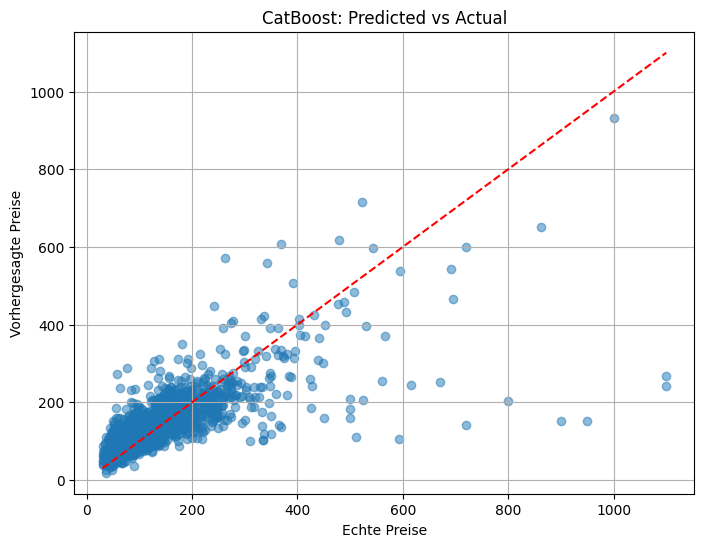

In [ ]:
#----- linear correction
y_pred = calibration_model.predict(y_pred.reshape(-1, 1))

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("Echte Preise")
plt.ylabel("Vorhergesagte Preise")
plt.title("CatBoost: Predicted vs Actual")
plt.grid(True)
plt.show()

MAE: 42.72388667404666
RMSE: 77.53269665833776


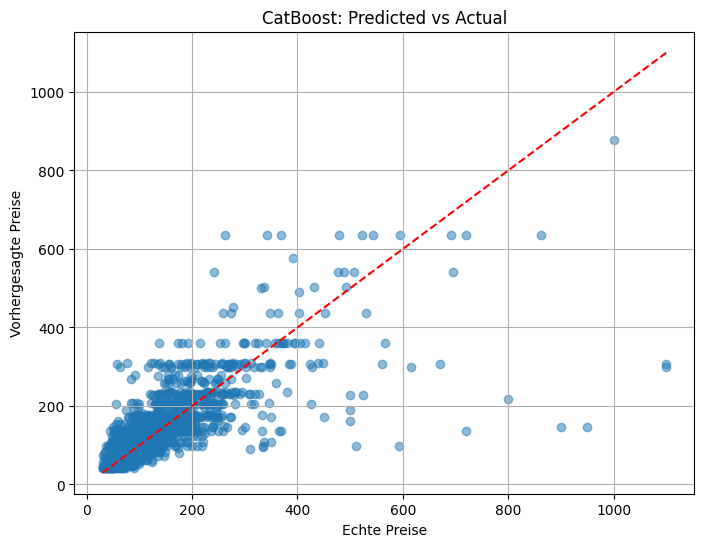

In [ ]:
#----- isotonic correction
y_pred = isotonic_model.predict(y_pred.reshape(-1, 1))

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("Echte Preise")
plt.ylabel("Vorhergesagte Preise")
plt.title("CatBoost: Predicted vs Actual")
plt.grid(True)
plt.show()

MAE: 51.67595347579339
RMSE: 107.17856637359704
MAE: 51.67595347579339
RMSE: 107.17856637359704


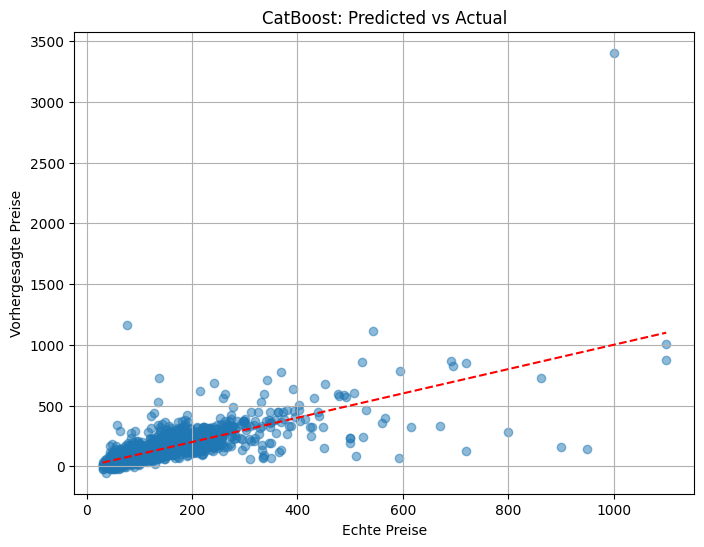

In [ ]:
#----- catboost residual correction
pred_residuals = residual_model.predict(X_test)

true_residuals = y_test - y_pred

mae = mean_absolute_error(true_residuals, pred_residuals)
rmse = np.sqrt(mean_squared_error(true_residuals, pred_residuals))

print("MAE:", mae)
print("RMSE:", rmse)

y_pred = (
    y_pred
    + pred_residuals
)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.xlabel("Echte Preise")
plt.ylabel("Vorhergesagte Preise")
plt.title("CatBoost: Predicted vs Actual")
plt.grid(True)
plt.show()
